# Benchmarking Notebook

Benchmarking **DFS** and **A*** on **Sudoku** and **Net** (pipes) puzzles at various sizes / difficulties. 
This version iterates over available heuristics for A*.

## 1 · Setup

In [17]:
# Clone repo (skip if already cloned)
import os
if not os.path.isdir('IntroAiAssignment1'):
    !git clone git@github.com:namanhishere/IntroAiAssignment1.git

In [1]:
!pip install -q -r ./IntroAiAssignment1/requirements.txt
!pip install -q psutil py-cpuinfo matplotlib pandas tabulate

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("IntroAiAssignment1"))

In [3]:
from algorithms.dfs import DFS
from algorithms.astar import AStar
from domain import SudokuProblem, NetProblem
from generator.create_sodoku import generate_sudoku_puzzle
from generator.create_net import generate_net_puzzle

In [4]:
import random
import numpy as np
import time
import tracemalloc
import signal
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tabulate import tabulate

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 2 · System Information

In [5]:
import platform, psutil
try:
    from cpuinfo import get_cpu_info
    cpu_name = get_cpu_info()['brand_raw']
except Exception:
    cpu_name = platform.processor()

print("-" * 40)
print("SYSTEM BENCHMARK METADATA")
print("-" * 40)
print(f"OS             : {platform.system()} {platform.release()} ({platform.architecture()[0]})")
print(f"Python Version : {platform.python_version()}")
print(f"CPU Model      : {cpu_name}")
print(f"Physical Cores : {psutil.cpu_count(logical=False)}")
print(f"Total Threads  : {psutil.cpu_count(logical=True)}")
cpufreq = psutil.cpu_freq()
if cpufreq:
    print(f"Max Frequency  : {cpufreq.max:.2f} MHz")
svmem = psutil.virtual_memory()
print(f"Total RAM      : {svmem.total / (1024**3):.2f} GB")
print("-" * 40)

----------------------------------------
SYSTEM BENCHMARK METADATA
----------------------------------------
OS             : Linux 6.8.0-100-generic (64bit)
Python Version : 3.12.3
CPU Model      : QEMU Virtual CPU version 2.5+
Physical Cores : 6
Total Threads  : 6
Max Frequency  : 0.00 MHz
Total RAM      : 10.12 GB
----------------------------------------


## 3 · Benchmark Helper

In [6]:
TIMEOUT = 120  # seconds per single run


class _Timeout(Exception):
    pass


def _alarm_handler(signum, frame):
    raise _Timeout()


def run_benchmark(algorithm, problem, timeout=TIMEOUT):
    """
    Run a single benchmark for *algorithm* on *problem*.

    Returns dict with:
        solved, time_s, steps, path_length, peak_memory_mb, timed_out
    """
    result_dict = {
        'solved': False,
        'time_s': None,
        'steps': None,
        'path_length': None,
        'peak_memory_mb': None,
        'timed_out': False,
    }

    old_handler = signal.signal(signal.SIGALRM, _alarm_handler)
    signal.alarm(timeout)

    tracemalloc.start()
    t0 = time.perf_counter()

    try:
        goal_node = algorithm.solve_benchmark(problem)
        t1 = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        result_dict['time_s'] = round(t1 - t0, 4)
        result_dict['steps'] = algorithm.step_count
        result_dict['peak_memory_mb'] = round(peak / 1024 / 1024, 2)

        if goal_node is not None:
            result_dict['solved'] = True
            result_dict['path_length'] = len(goal_node.solution())

    except _Timeout:
        t1 = time.perf_counter()
        if tracemalloc.is_tracing():
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            result_dict['peak_memory_mb'] = round(peak / 1024 / 1024, 2)
        result_dict['timed_out'] = True
        result_dict['time_s'] = round(t1 - t0, 4)
        result_dict['steps'] = algorithm.step_count

    except Exception as e:
        t1 = time.perf_counter()
        if tracemalloc.is_tracing():
            tracemalloc.stop()
        result_dict['time_s'] = round(t1 - t0, 4)
        result_dict['error'] = str(e)
        raise Exception(e)

    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old_handler)

    return result_dict

### Algorithm Registry

In [7]:
ALGORITHMS = {
    'DFS': lambda: DFS(),
    'A*':  lambda: AStar(),
}

---
## 4 · Sudoku Benchmark

### 4.1 Generate Sudoku Puzzles

Different difficulty = different number of cells removed.

In [8]:
SUDOKU_LEVELS = {
    'Easy (30)':   30,
    'Medium (40)': 40,
    'Hard (50)':   50,
    'Max':         'max',
}

NUM_SUDOKU_TRIALS = 3

sudoku_puzzles = {}  # level_name -> list[grid]

for level_name, level_val in SUDOKU_LEVELS.items():
    puzzles = []
    for trial in range(NUM_SUDOKU_TRIALS):
        seed = 1000 + trial
        grid = generate_sudoku_puzzle(seed=seed, level=level_val)
        clues = sum(1 for row in grid for c in row if c != 0)
        puzzles.append(grid)
        print(f"  {level_name} trial {trial}: {clues} clues")
    sudoku_puzzles[level_name] = puzzles
    print()

print("✅ Sudoku puzzle generation complete.")

--> Removed 30 cells.
  Easy (30) trial 0: 51 clues
--> Removed 30 cells.
  Easy (30) trial 1: 51 clues
--> Removed 30 cells.
  Easy (30) trial 2: 51 clues

--> Removed 40 cells.
  Medium (40) trial 0: 41 clues
--> Removed 40 cells.
  Medium (40) trial 1: 41 clues
--> Removed 40 cells.
  Medium (40) trial 2: 41 clues

--> Removed 50 cells.
  Hard (50) trial 0: 31 clues
--> Removed 50 cells.
  Hard (50) trial 1: 31 clues
--> Removed 50 cells.
  Hard (50) trial 2: 31 clues

--> Removed 57 cells.
  Max trial 0: 24 clues
--> Removed 55 cells.
  Max trial 1: 26 clues
--> Removed 57 cells.
  Max trial 2: 24 clues

✅ Sudoku puzzle generation complete.


### 4.2 Run Sudoku Benchmarks

Iterating over heuristics for A*.

In [9]:
sudoku_results = []

for level_name, puzzles in sudoku_puzzles.items():
    for trial_idx, grid in enumerate(puzzles):
        for algo_base_name, algo_factory in ALGORITHMS.items():
            if algo_base_name == 'A*':
                # Iterate over all available heuristics in SudokuProblem
                heuristics = SudokuProblem.HEURISTIC_FUNCTION
                for h_name, _ in heuristics:
                    problem = SudokuProblem(grid, heuristic=h_name)
                    algo = algo_factory()
                    algo_display_name = f"{algo_base_name} ({h_name})"
                    
                    print(f"  {algo_display_name} | Sudoku {level_name} trial {trial_idx} ... ", end='', flush=True)
                    res = run_benchmark(algo, problem)
                    tag = '✅' if res['solved'] else ('⏱ TIMEOUT' if res.get('timed_out') else '❌')
                    print(f"{tag}  time={res['time_s']}s  steps={res['steps']}")

                    sudoku_results.append({
                        'Game': 'Sudoku',
                        'Difficulty': level_name,
                        'Trial': trial_idx,
                        'Algorithm': algo_display_name,
                        **res,
                    })
            else:
                # DFS or other algorithms that don't take a heuristic
                problem = SudokuProblem(grid)
                algo = algo_factory()
                print(f"  {algo_base_name} | Sudoku {level_name} trial {trial_idx} ... ", end='', flush=True)
                res = run_benchmark(algo, problem)
                tag = '✅' if res['solved'] else ('⏱ TIMEOUT' if res.get('timed_out') else '❌')
                print(f"{tag}  time={res['time_s']}s  steps={res['steps']}")
                
                sudoku_results.append({
                    'Game': 'Sudoku',
                    'Difficulty': level_name,
                    'Trial': trial_idx,
                    'Algorithm': algo_base_name,
                    **res,
                })

df_sudoku = pd.DataFrame(sudoku_results)
print("\n✅ Sudoku benchmarks complete.")

  DFS | Sudoku Easy (30) trial 0 ... ✅  time=0.0081s  steps=35
  A* (cells) | Sudoku Easy (30) trial 0 ... ✅  time=0.0093s  steps=42
  A* (zero) | Sudoku Easy (30) trial 0 ... ✅  time=0.0084s  steps=42
  A* (srv) | Sudoku Easy (30) trial 0 ... ✅  time=0.0093s  steps=42
  A* (mrv) | Sudoku Easy (30) trial 0 ... ✅  time=0.0239s  steps=31
  DFS | Sudoku Easy (30) trial 1 ... ✅  time=0.007s  steps=36
  A* (cells) | Sudoku Easy (30) trial 1 ... ✅  time=0.0092s  steps=46
  A* (zero) | Sudoku Easy (30) trial 1 ... ✅  time=0.0088s  steps=46
  A* (srv) | Sudoku Easy (30) trial 1 ... ✅  time=0.0094s  steps=46
  A* (mrv) | Sudoku Easy (30) trial 1 ... ✅  time=0.028s  steps=33
  DFS | Sudoku Easy (30) trial 2 ... ✅  time=0.0076s  steps=40
  A* (cells) | Sudoku Easy (30) trial 2 ... ✅  time=0.009s  steps=44
  A* (zero) | Sudoku Easy (30) trial 2 ... ✅  time=0.0088s  steps=44
  A* (srv) | Sudoku Easy (30) trial 2 ... ✅  time=0.0089s  steps=44
  A* (mrv) | Sudoku Easy (30) trial 2 ... ✅  time=0.0248s

### 4.3 Sudoku Results Table

In [10]:
sudoku_summary = df_sudoku.groupby(['Difficulty', 'Algorithm']).agg(
    Solved=('solved', 'sum'),
    Total=('solved', 'count'),
    Avg_Time_s=('time_s', 'mean'),
    Avg_Steps=('steps', 'mean'),
    Avg_Path_Length=('path_length', 'mean'),
    Avg_Peak_Memory_MB=('peak_memory_mb', 'mean'),
).reset_index()

sudoku_summary['Avg_Time_s'] = sudoku_summary['Avg_Time_s'].round(4)
sudoku_summary['Avg_Steps'] = sudoku_summary['Avg_Steps'].round(0).astype('Int64')
sudoku_summary['Avg_Path_Length'] = sudoku_summary['Avg_Path_Length'].round(1)
sudoku_summary['Avg_Peak_Memory_MB'] = sudoku_summary['Avg_Peak_Memory_MB'].round(2)

print("=" * 100)
print(f"SUDOKU BENCHMARK RESULTS  (averaged over {NUM_SUDOKU_TRIALS} trials)")
print("=" * 100)
print(tabulate(sudoku_summary, headers='keys', tablefmt='github', showindex=False))

SUDOKU BENCHMARK RESULTS  (averaged over 3 trials)
| Difficulty   | Algorithm   |   Solved |   Total |   Avg_Time_s |   Avg_Steps |   Avg_Path_Length |   Avg_Peak_Memory_MB |
|--------------|-------------|----------|---------|--------------|-------------|-------------------|----------------------|
| Easy (30)    | A* (cells)  |        3 |       3 |       0.0092 |          44 |              30   |                 0.07 |
| Easy (30)    | A* (mrv)    |        3 |       3 |       0.0256 |          32 |              30   |                 0.08 |
| Easy (30)    | A* (srv)    |        3 |       3 |       0.0092 |          44 |              30   |                 0.07 |
| Easy (30)    | A* (zero)   |        3 |       3 |       0.0087 |          44 |              30   |                 0.07 |
| Easy (30)    | DFS         |        3 |       3 |       0.0076 |          37 |              30   |                 0.07 |
| Hard (50)    | A* (cells)  |        3 |       3 |       2.2412 |        9370 | 

### 4.4 Sudoku Visualizations

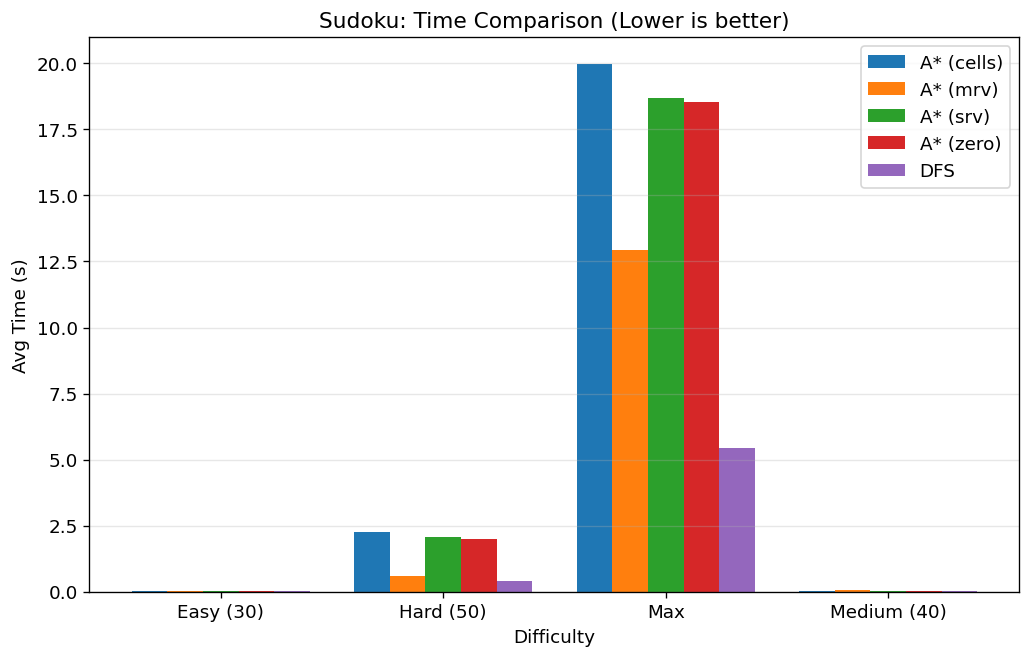

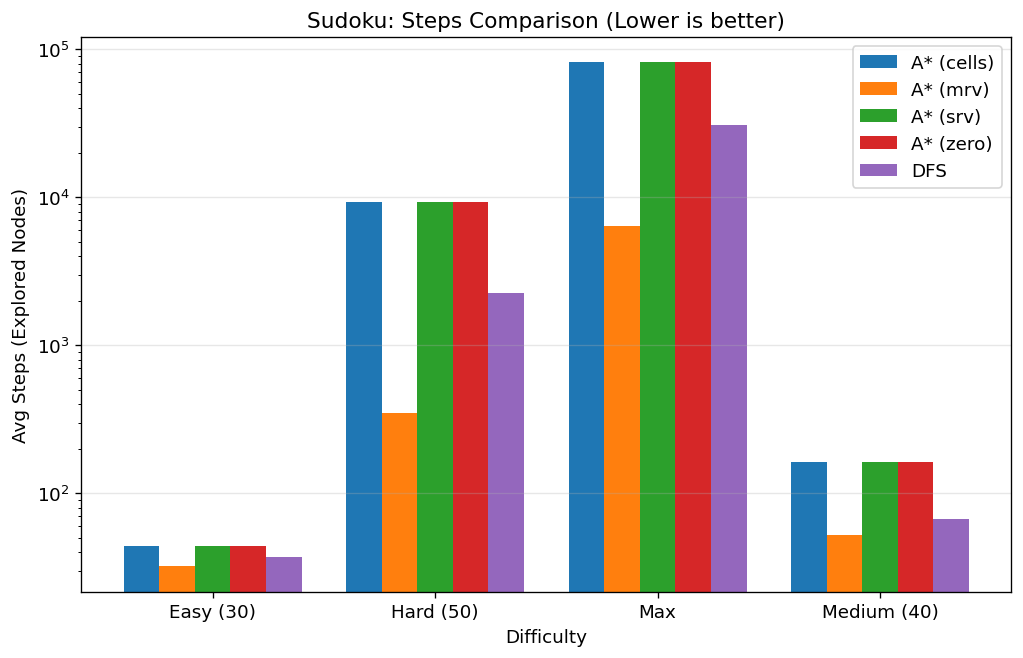

In [11]:
df_plot = sudoku_summary.copy()
algo_names = df_plot['Algorithm'].unique()
diff_names = df_plot['Difficulty'].unique()

# Bar chart: Execution Time
plt.figure(figsize=(10, 6))
x = np.arange(len(diff_names))
width = 0.8 / len(algo_names)

for i, algo in enumerate(algo_names):
    subset = df_plot[df_plot['Algorithm'] == algo]
    # Align with diff_names order
    subset = subset.set_index('Difficulty').reindex(diff_names).reset_index()
    plt.bar(x + i*width, subset['Avg_Time_s'], width, label=algo)

plt.xlabel('Difficulty')
plt.ylabel('Avg Time (s)')
plt.title('Sudoku: Time Comparison (Lower is better)')
plt.xticks(x + width*(len(algo_names)-1)/2, diff_names)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Bar chart: Steps
plt.figure(figsize=(10, 6))
for i, algo in enumerate(algo_names):
    subset = df_plot[df_plot['Algorithm'] == algo]
    subset = subset.set_index('Difficulty').reindex(diff_names).reset_index()
    plt.bar(x + i*width, subset['Avg_Steps'], width, label=algo)

plt.xlabel('Difficulty')
plt.ylabel('Avg Steps (Explored Nodes)')
plt.title('Sudoku: Steps Comparison (Lower is better)')
plt.xticks(x + width*(len(algo_names)-1)/2, diff_names)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')  # Log scale for steps often helps
plt.show()

---
## 5 · Net (Pipes) Benchmark

### 5.1 Generate Net Puzzles

Sizes: 3x3 up to 7x7.

In [12]:
NET_SIZES = [3, 4, 5, 6, 7]
NUM_NET_TRIALS = 3

net_puzzles = {}  # size -> list[grid]

for size in NET_SIZES:
    puzzles = []
    for trial in range(NUM_NET_TRIALS):
        seed = 2000 + (size * 100) + trial
        # Generate
        grid = generate_net_puzzle(size=size, seed=seed, scramble=True)
        puzzles.append(grid)
        # Just verify creating a problem works
        _ = NetProblem(grid)
    net_puzzles[size] = puzzles
    print(f"  Generated {NUM_NET_TRIALS} puzzles of size {size}x{size}")

print("\n✅ Net puzzle generation complete.")

  Generated 3 puzzles of size 3x3
  Generated 3 puzzles of size 4x4
  Generated 3 puzzles of size 5x5
  Generated 3 puzzles of size 6x6
  Generated 3 puzzles of size 7x7

✅ Net puzzle generation complete.


### 5.2 Run Net Benchmarks

Iterating over heuristics for A*.

In [13]:
net_results = []

for size, puzzles in net_puzzles.items():
    for trial_idx, grid in enumerate(puzzles):
        for algo_base_name, algo_factory in ALGORITHMS.items():
            if algo_base_name == 'A*':
                # Iterate over all available heuristics in NetProblem
                heuristics = NetProblem.HEURISTIC_FUNCTIONS
                for h_name, _ in heuristics:
                    # Create problem with specific heuristic
                    problem = NetProblem(grid, heuristic=h_name)
                    algo = algo_factory()
                    algo_display_name = f"{algo_base_name} ({h_name})"
                    
                    print(f"  {algo_display_name} | Net {size}x{size} trial {trial_idx} ... ", end='', flush=True)
                    res = run_benchmark(algo, problem)
                    tag = '✅' if res['solved'] else ('⏱ TIMEOUT' if res.get('timed_out') else '❌')
                    print(f"{tag}  time={res['time_s']}s  steps={res['steps']}")
                    
                    net_results.append({
                        'Game': 'Net',
                        'Size': f"{size}x{size}",
                        'Trial': trial_idx,
                        'Algorithm': algo_display_name,
                        **res,
                    })
            else:
                # DFS
                problem = NetProblem(grid)
                algo = algo_factory()
                print(f"  {algo_base_name} | Net {size}x{size} trial {trial_idx} ... ", end='', flush=True)
                res = run_benchmark(algo, problem)
                tag = '✅' if res['solved'] else ('⏱ TIMEOUT' if res.get('timed_out') else '❌')
                print(f"{tag}  time={res['time_s']}s  steps={res['steps']}")
                
                net_results.append({
                    'Game': 'Net',
                    'Size': f"{size}x{size}",
                    'Trial': trial_idx,
                    'Algorithm': algo_base_name,
                    **res,
                })

df_net = pd.DataFrame(net_results)
print("\n✅ Net benchmarks complete.")

  DFS | Net 3x3 trial 0 ... ✅  time=0.0016s  steps=11
  A* (cells) | Net 3x3 trial 0 ... ✅  time=0.001s  steps=13
  A* (zero) | Net 3x3 trial 0 ... ✅  time=0.001s  steps=13
  A* (lookahead) | Net 3x3 trial 0 ... ✅  time=0.0014s  steps=10
  A* (connectivity) | Net 3x3 trial 0 ... ✅  time=0.0014s  steps=13
  DFS | Net 3x3 trial 1 ... ✅  time=0.0009s  steps=15
  A* (cells) | Net 3x3 trial 1 ... ✅  time=0.0012s  steps=15
  A* (zero) | Net 3x3 trial 1 ... ✅  time=0.0012s  steps=15
  A* (lookahead) | Net 3x3 trial 1 ... ✅  time=0.0014s  steps=12
  A* (connectivity) | Net 3x3 trial 1 ... ✅  time=0.0015s  steps=14
  DFS | Net 3x3 trial 2 ... ✅  time=0.001s  steps=10
  A* (cells) | Net 3x3 trial 2 ... ✅  time=0.0014s  steps=12
  A* (zero) | Net 3x3 trial 2 ... ✅  time=0.0013s  steps=12
  A* (lookahead) | Net 3x3 trial 2 ... ✅  time=0.0016s  steps=10
  A* (connectivity) | Net 3x3 trial 2 ... ✅  time=0.0014s  steps=10
  DFS | Net 4x4 trial 0 ... ✅  time=0.0017s  steps=17
  A* (cells) | Net 4x4 tr

### 5.3 Net Results Table

In [14]:
net_summary = df_net.groupby(['Size', 'Algorithm']).agg(
    Solved=('solved', 'sum'),
    Total=('solved', 'count'),
    Avg_Time_s=('time_s', 'mean'),
    Avg_Steps=('steps', 'mean'),
    Avg_Path_Length=('path_length', 'mean'),
    Avg_Peak_Memory_MB=('peak_memory_mb', 'mean'),
).reset_index()

net_summary['Avg_Time_s'] = net_summary['Avg_Time_s'].round(4)
net_summary['Avg_Steps'] = net_summary['Avg_Steps'].round(0).astype('Int64')
net_summary['Avg_Path_Length'] = net_summary['Avg_Path_Length'].round(1)
net_summary['Avg_Peak_Memory_MB'] = net_summary['Avg_Peak_Memory_MB'].round(2)

print("=" * 100)
print(f"NET BENCHMARK RESULTS  (averaged over {NUM_NET_TRIALS} trials)")
print("=" * 100)
print(tabulate(net_summary, headers='keys', tablefmt='github', showindex=False))

NET BENCHMARK RESULTS  (averaged over 3 trials)
| Size   | Algorithm         |   Solved |   Total |   Avg_Time_s |   Avg_Steps |   Avg_Path_Length |   Avg_Peak_Memory_MB |
|--------|-------------------|----------|---------|--------------|-------------|-------------------|----------------------|
| 3x3    | A* (cells)        |        3 |       3 |       0.0012 |          13 |                 9 |                 0.01 |
| 3x3    | A* (connectivity) |        3 |       3 |       0.0014 |          12 |                 9 |                 0.01 |
| 3x3    | A* (lookahead)    |        3 |       3 |       0.0015 |          11 |                 9 |                 0.01 |
| 3x3    | A* (zero)         |        3 |       3 |       0.0012 |          13 |                 9 |                 0.01 |
| 3x3    | DFS               |        3 |       3 |       0.0012 |          12 |                 9 |                 0.01 |
| 4x4    | A* (cells)        |        3 |       3 |       0.0018 |          20 |    

### 5.4 Net Visualizations

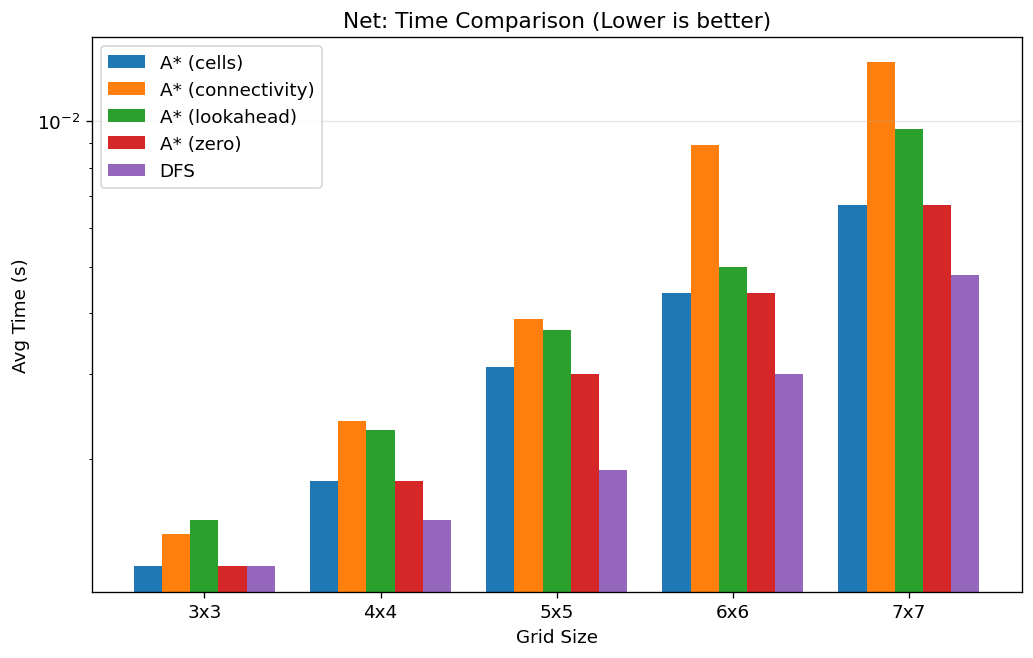

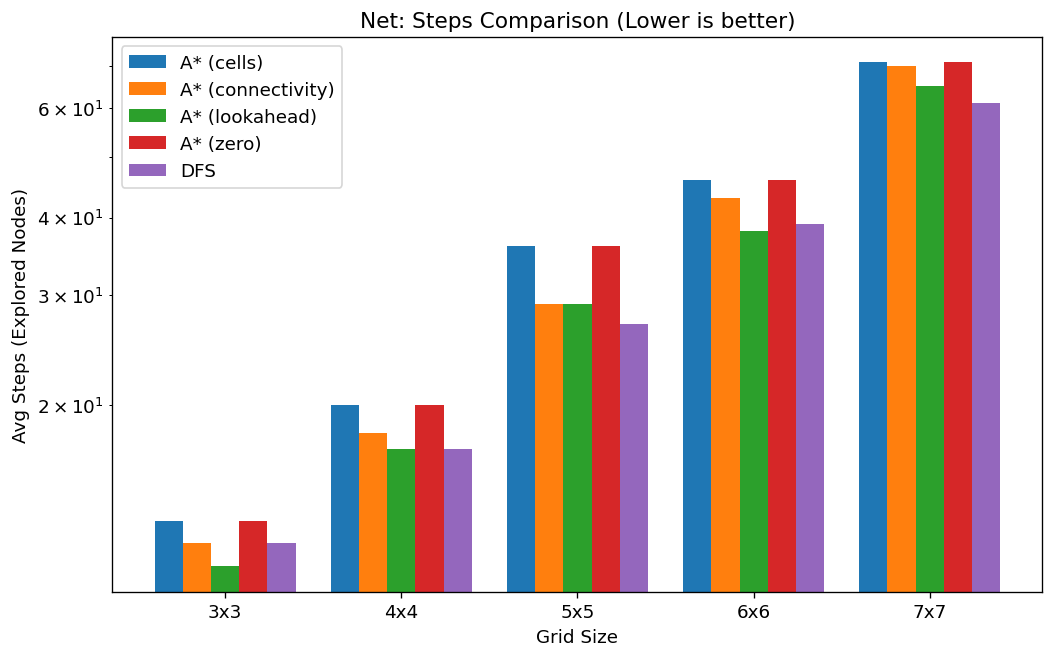

In [15]:
df_plot_net = net_summary.copy()
# Ensure sorted by size for plotting
df_plot_net['SizeInt'] = df_plot_net['Size'].apply(lambda x: int(x.split('x')[0]))
df_plot_net = df_plot_net.sort_values('SizeInt')

algo_names_net = df_plot_net['Algorithm'].unique()
size_names = df_plot_net['Size'].unique()

# Bar chart: Time
plt.figure(figsize=(10, 6))
x = np.arange(len(size_names))
width = 0.8 / len(algo_names_net)

for i, algo in enumerate(algo_names_net):
    subset = df_plot_net[df_plot_net['Algorithm'] == algo]
    subset = subset.set_index('Size').reindex(size_names).reset_index()
    plt.bar(x + i*width, subset['Avg_Time_s'], width, label=algo)

plt.xlabel('Grid Size')
plt.ylabel('Avg Time (s)')
plt.title('Net: Time Comparison (Lower is better)')
plt.xticks(x + width*(len(algo_names_net)-1)/2, size_names)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')
plt.show()

# Bar chart: Steps
plt.figure(figsize=(10, 6))
for i, algo in enumerate(algo_names_net):
    subset = df_plot_net[df_plot_net['Algorithm'] == algo]
    subset = subset.set_index('Size').reindex(size_names).reset_index()
    plt.bar(x + i*width, subset['Avg_Steps'], width, label=algo)

plt.xlabel('Grid Size')
plt.ylabel('Avg Steps (Explored Nodes)')
plt.title('Net: Steps Comparison (Lower is better)')
plt.xticks(x + width*(len(algo_names_net)-1)/2, size_names)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')
plt.show()

## 6 · Combined Results / Export

Saving results to `benchmark_results.csv`.

In [16]:
df_all = pd.concat([df_sudoku, df_net], ignore_index=True)

# Create a 'Puzzle' column for clearer grouping
df_all['Puzzle'] = df_all.apply(
    lambda r: f"Sudoku {r['Difficulty']}" if r['Game'] == 'Sudoku' 
              else f"Net {r['Size']}",
    axis=1
)

# Save
df_all.to_csv('benchmark_results.csv', index=False)
print("Saved all raw results to 'benchmark_results.csv'.")

print("\nHEAD of combined results:")
print(tabulate(df_all.head(10), headers='keys', tablefmt='psql', showindex=False))

Saved all raw results to 'benchmark_results.csv'.

HEAD of combined results:
+--------+--------------+---------+-------------+----------+----------+---------+---------------+------------------+-------------+--------+------------------+
| Game   | Difficulty   |   Trial | Algorithm   | solved   |   time_s |   steps |   path_length |   peak_memory_mb | timed_out   |   Size | Puzzle           |
|--------+--------------+---------+-------------+----------+----------+---------+---------------+------------------+-------------+--------+------------------|
| Sudoku | Easy (30)    |       0 | DFS         | True     |   0.0081 |      35 |            30 |             0.08 | False       |    nan | Sudoku Easy (30) |
| Sudoku | Easy (30)    |       0 | A* (cells)  | True     |   0.0093 |      42 |            30 |             0.07 | False       |    nan | Sudoku Easy (30) |
| Sudoku | Easy (30)    |       0 | A* (zero)   | True     |   0.0084 |      42 |            30 |             0.07 | False      